# Explore the bee microbiome use case

In [168]:
from pathlib import Path
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
from matplotlib import colors as mcolors


import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [70]:
data_dp = Path("../data/use-cases/bee-microbiome/")
data_dp.exists()

data_dp_2 = Path("../data/bee-use-case/")
data_dp_2.exists()

result_dp = Path("../results/bee-use-case/")
result_dp.exists()

True

In [3]:
expert_evaluation_fp = data_dp / "expert_evaluation.xlsx"
df_expert = pd.read_excel(expert_evaluation_fp)

# Quick overview
print(f"Rows: {len(df_expert)}")
print(f"Columns: {df_expert.shape[1]}")

Rows: 48
Columns: 22


In [137]:
reps_fp = result_dp / "reps_bee.tsv"
reps_df = pd.read_csv(reps_fp, sep="\t")
# Quick overview
print(f"Rows: {len(reps_df)}")
print(f"Columns: {reps_df.shape[1]}")
reps_df.head()

Rows: 38
Columns: 350


,MAG,Domain,Phylum,Class,Order,Family,Genus,Species,Cluster members,Completeness,...,"kegg_Vancomycin resistance, D-Ala-D-Ser type","kegg_Vibrio cholerae pathogenicity signature, cholera toxins","kegg_Vibrio cholerae pathogenicity signature, toxin coregulated pilus","kegg_Xanthomonas spp. pathogenicity signature, T3SS and effectors","kegg_Xylene degradation, xylene => methylbenzoate","kegg_beta-Carotene biosynthesis, GGAP => beta-carotene","kegg_beta-Lactam resistance, Bla system",kegg_beta-Oxidation,"kegg_beta-Oxidation, acyl-CoA synthesis",kegg_dTDP-L-rhamnose biosynthesis
0,SRR24759608_bin_64934,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Providencia,Providencia alcalifaciens,2,100.0%,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,SRR24759606_bin_47167,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Providencia,Providencia rettgeri_D,1,100.0%,...,NaN,NaN,NaN,6.82,NaN,NaN,NaN,100.0,100.0,83.33
2,SRR24759616_bin_33137,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Proteus,Proteus mirabilis,12,100.0%,...,NaN,NaN,NaN,5.68,NaN,NaN,NaN,100.0,100.0,100.00
3,SRR24759605_bin_35353,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Arsenophonus,Arsenophonus apicola,1,100.0%,...,NaN,NaN,7.14,10.23,NaN,NaN,33.33,100.0,100.0,83.33
4,SRR24759598_bin_98484,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Klebsiella,Klebsiella oxytoca,9,100.0%,...,NaN,NaN,NaN,NaN,33.33,NaN,33.33,100.0,100.0,83.33


In [138]:
metadata_df = pd.read_csv(data_dp_2 / "metadata.tsv", sep="\t")
metadata_df["Replicate"] = metadata_df["Replicate"].astype(str).str.replace(r"\s+Replicate", "", regex=True)
metadata_df.head()

,Run accession,Sample accession,Sample alias,Replicate,Condition,Experimental condition,Infection by Nosema ceranae,Chronic exposure to neonicotinoid,Treatment with probiotic
0,SRR24759600,SAMN35523847,II3,NT3,NT,infection by N. ceranae then chronic exposure ...,True,True,False
1,SRR24759601,SAMN35523846,II2,NT2,NT,infection by N. ceranae then chronic exposure ...,True,True,False
2,SRR24759604,SAMN35523841,I3,N3,N,infection by N. ceranae,True,False,False
3,SRR24759608,SAMN35523834,SI2,T2,T,chronic exposure to 1.5 ng/mL thiamethoxam,False,True,False
4,SRR24759609,SAMN35523833,SI1,T1,T,chronic exposure to 1.5 ng/mL thiamethoxam,False,True,False


# MAGs assigned taxonomy

In [5]:
levels = pd.DataFrame(0, index=["Genus", "Species"], columns=["count", "Species-level MAG count"])

for l in levels.index:
    if l in df_expert.columns:
        levels.loc[l, "count"] = df_expert[l].notna().sum()
        levels.loc[l, "Species-level MAG count"] = df_expert.loc[df_expert[l].notna(), "Species-level MAG count"].sum()
    else:
        print(f"Column '{l}' not found in the DataFrame.")
levels

,count,Species-level MAG count
Genus,38,161
Species,32,148


In [6]:
100*levels.loc["Species","Species-level MAG count"]/levels.loc["Genus","Species-level MAG count"]

np.float64(91.92546583850931)

In [7]:
def get_level_counts(df, level):
    """
    Get counts of non-empty values for a taxonomic level in the DataFrame.
    
    Parameters:
    df (pd.DataFrame): The input DataFrame.
    level (str): The level to group by in the DataFrame.
    
    Returns:
    pd.DataFrame: A DataFrame with counts and Species-level MAG counts for each level.
    """
    level_group = df.groupby(level)

    # Create count summary
    level_counts = level_group.size().sort_values(ascending=False).to_frame("count")
    level_counts["percentage"] = 100*level_counts["count"] / level_counts["count"].sum()

    # Create MAG count summary
    level_mag_counts = level_group["Species-level MAG count"].sum().sort_values(ascending=False).to_frame("Total MAG count")

    # Merge the two dataframes
    level_summary = pd.concat([level_counts, level_mag_counts], axis=1)
    level_summary.sort_values(by="Total MAG count", ascending=False, inplace=True)

    # Add totals row
    level_summary.loc["TOTAL"] = level_summary.sum(numeric_only=True)
    level_summary.loc["TOTAL", "percentage"] = 100.0  # Percentage for TOTAL should be 100

    return level_summary

display(get_level_counts(df_expert, "Phylum"))
display(get_level_counts(df_expert, "Class"))
display(get_level_counts(df_expert, "Order"))
display(get_level_counts(df_expert, "Family"))
display(get_level_counts(df_expert, "Genus"))
display(get_level_counts(df_expert, "Species"))

,count,percentage,Total MAG count
Phylum,,,
Pseudomonadota,23.0,60.526316,77.0
Bacillota,9.0,23.684211,58.0
Bacillota_A,4.0,10.526316,12.0
Actinomycetota,1.0,2.631579,8.0
Bacteroidota,1.0,2.631579,6.0
TOTAL,38.0,100.000000,161.0


,count,percentage,Total MAG count
Class,,,
Gammaproteobacteria,19.0,50.000000,70.0
Bacilli,9.0,23.684211,58.0
Clostridia,4.0,10.526316,12.0
Actinomycetes,1.0,2.631579,8.0
Alphaproteobacteria,4.0,10.526316,7.0
Bacteroidia,1.0,2.631579,6.0
TOTAL,38.0,100.000000,161.0


,count,percentage,Total MAG count
Order,,,
Lactobacillales,8.0,21.052632,57.0
Enterobacterales,13.0,34.210526,52.0
Lachnospirales,3.0,7.894737,11.0
Pseudomonadales,4.0,10.526316,9.0
Burkholderiales,2.0,5.263158,9.0
Actinomycetales,1.0,2.631579,8.0
Rhizobiales,4.0,10.526316,7.0
Flavobacteriales,1.0,2.631579,6.0
Bacillales_D,1.0,2.631579,1.0


,count,percentage,Total MAG count
Family,,,
Enterobacteriaceae,13.0,34.210526,52.0
Lactobacillaceae,7.0,18.421053,50.0
Lachnospiraceae,3.0,7.894737,11.0
Pseudomonadaceae,4.0,10.526316,9.0
Neisseriaceae,2.0,5.263158,9.0
Bifidobacteriaceae,1.0,2.631579,8.0
Rhizobiaceae,4.0,10.526316,7.0
Enterococcaceae,1.0,2.631579,7.0
Weeksellaceae,1.0,2.631579,6.0


,count,percentage,Total MAG count
Genus,,,
Apilactobacillus,2.0,5.263158,19.0
Frischella,1.0,2.631579,17.0
Fructobacillus,1.0,2.631579,17.0
Proteus,1.0,2.631579,12.0
Lactobacillus,3.0,7.894737,10.0
Novisyntrophococcus,2.0,5.263158,10.0
Klebsiella,1.0,2.631579,9.0
Entomomonas,4.0,10.526316,9.0
Snodgrassella,2.0,5.263158,9.0


,count,percentage,Total MAG count
Species,,,
Frischella perrara,1.0,3.125,17.0
Fructobacillus fructosus,1.0,3.125,17.0
Apilactobacillus kunkeei_C,1.0,3.125,15.0
Proteus mirabilis,1.0,3.125,12.0
Novisyntrophococcus liquoris,1.0,3.125,9.0
Klebsiella oxytoca,1.0,3.125,9.0
Snodgrassella alvi,1.0,3.125,8.0
Bifidobacterium indicum,1.0,3.125,8.0
Enterococcus faecalis,1.0,3.125,7.0


## Relative abundance

In [131]:
# combine coverage information with taxonomy information

coverage_fp = data_dp_2 / "coverm.tsv"
coverage_df = pd.read_csv(coverage_fp, sep="\t")

species_idx = reps_df.columns.get_loc("Species")
abund_df = reps_df.copy()
abund_df = abund_df.iloc[:, : species_idx + 1].copy()

abund_df = abund_df.merge(
    coverage_df,
    left_on="MAG",
    right_on="Genome",
    how="left",
)
abund_df = abund_df.drop(columns=["Genome"], errors="ignore")

run_to_replicate = metadata_df.set_index("Run accession")["Replicate"].to_dict()
abund_df = abund_df.rename(
    columns={
        column: run_to_replicate[column]
        for column in abund_df.columns
        if column.startswith("SRR") and column in run_to_replicate
    }
)

abund_df.head()

,MAG,Domain,Phylum,Class,Order,Family,Genus,Species,P1,NP3,...,T3,T2,T1,C3,C2,C1,P3,P2,N2,N1
0,SRR24759608_bin_64934,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Providencia,Providencia alcalifaciens,0.0,0.087898,...,0.189168,0.443102,0.008183,0.018827,0.025492,0.008592,0.000000,0.064481,0.060771,0.000000
1,SRR24759606_bin_47167,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Providencia,Providencia rettgeri_D,0.0,0.000000,...,0.094111,0.000000,0.000000,0.015835,0.000000,0.000000,0.000000,0.000000,0.023504,0.000000
2,SRR24759616_bin_33137,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Proteus,Proteus mirabilis,0.0,6.674429,...,0.891057,0.821687,0.028133,0.077728,0.095419,0.086834,0.048217,0.055019,0.900942,2.598924
3,SRR24759605_bin_35353,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Arsenophonus,Arsenophonus apicola,0.0,0.260814,...,0.000000,0.238163,0.296164,0.262830,0.231568,0.305046,0.430169,0.262127,0.271767,0.282202
4,SRR24759598_bin_98484,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Klebsiella,Klebsiella oxytoca,0.0,0.334291,...,0.060857,0.000000,0.085759,0.526849,0.296479,0.046071,0.159563,0.020098,0.218775,0.227393


In [143]:
species_abund_df = abund_df.groupby(["Family", "Genus", "Species"]).sum(numeric_only=True)

sample_order = [
    "C1", "C2", "C3",
    "P1", "P2", "P3",
    "T1", "T2", "T3",
    "TP1", "TP2", "TP3",
    "N1", "N2", "N3",
    "NP1", "NP2", "NP3",
    "NT1", "NT2", "NT3",
]
species_abund_df = species_abund_df[[*sample_order]]

species_abund_df = species_abund_df[sample_order].div(species_abund_df[sample_order].sum(axis=0), axis=1) * 100

species_abund_df.head()

C1  \
Family             Genus           Species                             
Amphibacillaceae   Virgibacillus   Virgibacillus proomii_B  1.229708   
Bifidobacteriaceae Bifidobacterium Bifidobacterium indicum  2.914923   
Enterobacteriaceae Arsenophonus    Arsenophonus apicola     0.660237   
                   Frischella      Frischella perrara       3.183809   
                   Gilliamella     Gilliamella apicola      1.545443   

                                                                  C2  \
Family             Genus           Species                             
Amphibacillaceae   Virgibacillus   Virgibacillus proomii_B  0.000000   
Bifidobacteriaceae Bifidobacterium Bifidobacterium indicum  5.336143   
Enterobacteriaceae Arsenophonus    Arsenophonus apicola     0.451788   
                   Frischella      Frischella perrara       3.131108   
                   Gilliamella     Gilliamella apicola      1.947186   

                                                                  C3  \
Family             Genus           Species                             
Amphibacillaceae   Virgibacillus   Virgibacillus proomii_B  0.014847   
Bifidobacteriaceae Bifidobacterium Bifidobacterium indicum  4.191349   
Enterobacteriaceae Arsenophonus    Arsenophonus apicola     0.514172   
                   Frischella      Frischella perrara       0.666841   
                   Gilliamella     Gilliamella apicola      1.245766   

                                                                  P1  \
Family             Genus           Species                             
Amphibacillaceae   Virgibacillus   Virgibacillus proomii_B  0.000000   
Bifidobacteriaceae Bifidobacterium Bifidobacterium indicum  2.491640   
Enterobacteriaceae Arsenophonus    Arsenophonus apicola     0.000000   
                   Frischella      Frischella perrara       5.434329   
                   Gilliamella     Gilliamella apicola      1.044959   

                                                                  P2  \
Family             Genus           Species                             
Amphibacillaceae   Virgibacillus   Virgibacillus proomii_B  0.000000   
Bifidobacteriaceae Bifidobacterium Bifidobacterium indicum  5.169363   
Enterobacteriaceae Arsenophonus    Arsenophonus apicola     0.514249   
                   Frischella      Frischella perrara       3.703817   
                   Gilliamella     Gilliamella apicola      1.943321   

                                                                  P3  \
Family             Genus           Species                             
Amphibacillaceae   Virgibacillus   Virgibacillus proomii_B  0.000000   
Bifidobacteriaceae Bifidobacterium Bifidobacterium indicum  3.188804   
Enterobacteriaceae Arsenophonus    Arsenophonus apicola     0.931716   
                   Frischella      Frischella perrara       2.988504   
                   Gilliamella     Gilliamella apicola      2.272571   

                                                                  T1  \
Family             Genus           Species                             
Amphibacillaceae   Virgibacillus   Virgibacillus proomii_B  0.000000   
Bifidobacteriaceae Bifidobacterium Bifidobacterium indicum  2.278937   
Enterobacteriaceae Arsenophonus    Arsenophonus apicola     0.628392   
                   Frischella      Frischella perrara       2.838377   
                   Gilliamella     Gilliamella apicola      1.135822   

                                                                  T2  \
Family             Genus           Species                             
Amphibacillaceae   Virgibacillus   Virgibacillus proomii_B  0.000000   
Bifidobacteriaceae Bifidobacterium Bifidobacterium indicum  4.241876   
Enterobacteriaceae Arsenophonus    Arsenophonus apicola     0.442469   
                   Frischella      Frischella perrara       0.504743   
                   Gilliamella     Gilliamella apicola      1.727883   

                          

### Relative abundance of control data

In [146]:
control_species_abund_df = species_abund_df[["C1", "C2", "C3"]]
control_species_abund_df.T.describe().T.sort_values(by="mean", ascending=False)

count  \
Family             Genus               Species                                 
Rhizobiaceae       Bartonella_A        unclassified                      3.0   
                                       Bartonella_A choladocola          3.0   
Enterobacteriaceae Gilliamella         Gilliamella apis_A                3.0   
Rhizobiaceae       Bartonella_A        Bartonella_A sp945285915          3.0   
Neisseriaceae      Snodgrassella       Snodgrassella alvi                3.0   
Bifidobacteriaceae Bifidobacterium     Bifidobacterium indicum           3.0   
Lactobacillaceae   Apilactobacillus    Apilactobacillus kunkeei_C        3.0   
                   Lactobacillus       Lactobacillus apis                3.0   
                                       Lactobacillus melliventris        3.0   
Enterobacteriaceae Frischella          Frischella perrara                3.0   
Lactobacillaceae   Lactobacillus       Lactobacillus helsingborgensis    3.0   
Enterobacteriaceae Gilliamella         Gilliamella apicola               3.0   
                                       Gilliamella apicola_N             3.0   
Lactobacillaceae   Fructobacillus      Fructobacillus fructosus          3.0   
Enterobacteriaceae Gilliamella         Gilliamella apicola_R             3.0   
                   Klebsiella          Klebsiella oxytoca                3.0   
                   Arsenophonus        Arsenophonus apicola              3.0   
Lachnospiraceae    Novisyntrophococcus Novisyntrophococcus liquoris      3.0   
Lactobacillaceae   Apilactobacillus    Apilactobacillus apinorum         3.0   
                   Bombilactobacillus  Bombilactobacillus mellis         3.0   
Amphibacillaceae   Virgibacillus       Virgibacillus proomii_B           3.0   
Enterococcaceae    Enterococcus        Enterococcus faecalis             3.0   
Enterobacteriaceae Providencia         Providencia rettgeri              3.0   
Neisseriaceae      Snodgrassella       Snodgrassella alvi_G              3.0   
Weeksellaceae      Apibacter           Apibacter sp945280365             3.0   
Enterobacteriaceae Proteus             Proteus mirabilis                 3.0   
                   Gilliamella         Gilliamella sp945271295           3.0   
Pseudomonadaceae   Entomomonas         unclassified                      3.0   
Lachnospiraceae    Novisyntrophococcus unclassified                      3.0   
                   Mobilisporobacter   unclassified                      3.0   
Pseudomonadaceae   Entomomonas         Entomomonas sp945283395           3.0   
Enterobacteriaceae Providencia         Providencia alcalifaciens         3.0   
Pseudomonadaceae   Entomomonas         Entomomonas moraniae              3.0   
Enterobacteriaceae Serratia            Serratia ureilytica               3.0   
                   Providencia         Providencia rettgeri_D            3.0   
Tepidimicrobiaceae Schnuerera          Schnuerera sp021655095            3.0   

                                                                            mean  \
Family             Genus               Species                                     
Rhizobiaceae       Bartonella_A        unclassified                    42.488926   
                                       Bartonella_A choladocola        16.255337   
Enterobacteriaceae Gilliamella         Gilliamella apis_A               5.231149   
Rhizobiaceae       Bartonella_A        Bartonella_A sp945285915         4.330412   
Neisseriaceae      Snodgrassella       Snodgrassella alvi               4.173978   
Bifidobacteriaceae Bifidobacterium     Bifidobacterium indicum          4.147472   
Lactobacillaceae   Apilactobacillus    Apilactobacillus kunkeei_C       3.668888   
                   Lactobacillus       Lactobacillus apis               2.990514   
                                       Lactobacillus melliventris       2.831876   
Enterobacteriaceae Frischella          Frischella perrara               2.327253   
Lactobacillaceae   Lac

In [150]:
control_species_abund_df.xs("Bartonella_A", level=1, axis=0, drop_level=False).sum(axis=0).describe()

count     3.000000
mean     63.074675
std       6.727555
min      56.610533
25%      59.593086
50%      62.575640
75%      66.306746
max      70.037852
dtype: float64

### Relative abundance of all experimental conditions

In [156]:
family_abund = species_abund_df.groupby(level=["Family"]).sum()
family_abund.T.describe().T.sort_values(by="mean", ascending=False)

,count,mean,std,min,25%,50%,75%,max
Family,,,,,,,,
Rhizobiaceae,21.0,60.505580,7.591618,45.480977,56.610533,61.350515,64.777408,73.699800
Enterobacteriaceae,21.0,16.133637,5.985195,8.359945,10.391449,15.604288,19.485668,28.563726
Lactobacillaceae,21.0,11.413629,3.875610,5.701365,7.751968,11.151313,14.027810,18.554947
Neisseriaceae,21.0,5.282950,2.324024,2.019276,3.554161,4.798950,6.798180,10.470156
Bifidobacteriaceae,21.0,3.832472,1.232510,1.741362,3.058149,3.420026,4.747697,6.359980
Pseudomonadaceae,21.0,1.510607,2.726504,0.000000,0.176321,0.274110,0.962521,11.297384
Lachnospiraceae,21.0,0.577212,0.410183,0.092606,0.289339,0.481086,0.658089,1.431038
Weeksellaceae,21.0,0.311876,0.288424,0.000000,0.078152,0.168933,0.549101,1.034974
Enterococcaceae,21.0,0.298881,0.186620,0.000000,0.150152,0.322716,0.441370,0.574477


In [157]:
genus_abund = species_abund_df.groupby(level=["Genus"]).sum()
genus_abund.T.describe().T.sort_values(by="mean", ascending=False)

,count,mean,std,min,25%,50%,75%,max
Genus,,,,,,,,
Bartonella_A,21.0,60.505580,7.591618,45.480977,56.610533,61.350515,64.777408,73.699800
Gilliamella,21.0,8.847692,3.563307,4.258849,6.635353,7.939835,9.712341,17.572240
Lactobacillus,21.0,6.219665,2.838695,2.443484,4.094802,5.283360,8.100000,12.510318
Snodgrassella,21.0,5.282950,2.324024,2.019276,3.554161,4.798950,6.798180,10.470156
Apilactobacillus,21.0,4.002815,1.887933,1.215120,2.572510,3.826619,4.914010,8.417777
Bifidobacterium,21.0,3.832472,1.232510,1.741362,3.058149,3.420026,4.747697,6.359980
Frischella,21.0,2.987899,1.669882,0.504743,1.681749,2.988504,3.703817,6.355265
Proteus,21.0,2.151310,2.841544,0.000000,0.152058,1.526562,2.747867,12.392208
Entomomonas,21.0,1.510607,2.726504,0.000000,0.176321,0.274110,0.962521,11.297384


In [158]:
species_abund_df.T.describe().T.sort_values(by="mean", ascending=False)

count  \
Family             Genus               Species                                 
Rhizobiaceae       Bartonella_A        unclassified                     21.0   
                                       Bartonella_A choladocola         21.0   
Neisseriaceae      Snodgrassella       Snodgrassella alvi               21.0   
Rhizobiaceae       Bartonella_A        Bartonella_A sp945285915         21.0   
Bifidobacteriaceae Bifidobacterium     Bifidobacterium indicum          21.0   
Enterobacteriaceae Gilliamella         Gilliamella apis_A               21.0   
Lactobacillaceae   Apilactobacillus    Apilactobacillus kunkeei_C       21.0   
                   Lactobacillus       Lactobacillus apis               21.0   
Enterobacteriaceae Frischella          Frischella perrara               21.0   
                   Proteus             Proteus mirabilis                21.0   
Lactobacillaceae   Lactobacillus       Lactobacillus melliventris       21.0   
Enterobacteriaceae Gilliamella         Gilliamella apicola              21.0   
                                       Gilliamella apicola_N            21.0   
Lactobacillaceae   Lactobacillus       Lactobacillus helsingborgensis   21.0   
Pseudomonadaceae   Entomomonas         unclassified                     21.0   
Enterobacteriaceae Arsenophonus        Arsenophonus apicola             21.0   
                   Gilliamella         Gilliamella apicola_R            21.0   
Lactobacillaceae   Fructobacillus      Fructobacillus fructosus         21.0   
Enterobacteriaceae Gilliamella         Gilliamella sp945271295          21.0   
                   Klebsiella          Klebsiella oxytoca               21.0   
Lachnospiraceae    Novisyntrophococcus Novisyntrophococcus liquoris     21.0   
Lactobacillaceae   Bombilactobacillus  Bombilactobacillus mellis        21.0   
Neisseriaceae      Snodgrassella       Snodgrassella alvi_G             21.0   
Lactobacillaceae   Apilactobacillus    Apilactobacillus apinorum        21.0   
Enterobacteriaceae Providencia         Providencia rettgeri             21.0   
Weeksellaceae      Apibacter           Apibacter sp945280365            21.0   
Enterococcaceae    Enterococcus        Enterococcus faecalis            21.0   
Pseudomonadaceae   Entomomonas         Entomomonas moraniae             21.0   
Enterobacteriaceae Providencia         Providencia alcalifaciens        21.0   
Lachnospiraceae    Novisyntrophococcus unclassified                     21.0   
Pseudomonadaceae   Entomomonas         Entomomonas sp945283395          21.0   
Tepidimicrobiaceae Schnuerera          Schnuerera sp021655095           21.0   
Enterobacteriaceae Providencia         Providencia rettgeri_D           21.0   
Amphibacillaceae   Virgibacillus       Virgibacillus proomii_B          21.0   
Enterobacteriaceae Serratia            Serratia ureilytica              21.0   
Lachnospiraceae    Mobilisporobacter   unclassified                     21.0   

                                                                            mean  \
Family             Genus               Species                                     
Rhizobiaceae       Bartonella_A        unclassified                    40.165032   
                                       Bartonella_A choladocola        15.506520   
Neisseriaceae      Snodgrassella       Snodgrassella alvi               4.928714   
Rhizobiaceae       Bartonella_A        Bartonella_A sp945285915         4.834028   
Bifidobacteriaceae Bifidobacterium     Bifidobacterium indicum          3.832472   
Enterobacteriaceae Gilliamella         Gilliamella apis_A               3.772716   
Lactobacillaceae   Apilactobacillus    Apilactobacillus kunkeei_C       3.650920   
                   Lactobacillus       Lactobacillus apis               3.033031   
Enterobacteriaceae Frischella          Frischella perrara               2.987899   
                   Proteus             Proteus mirabilis                2.151310   
Lactobacillaceae   Lac

In [185]:
control_species_abund_df = species_abund_df[["C1", "C2", "C3"]]
display(control_species_abund_df.T.describe().T.sort_values(by="mean", ascending=False))

infected_species_abund_df = species_abund_df[["N1", "N2", "N3"]]
display(infected_species_abund_df.T.describe().T.sort_values(by="mean", ascending=False))

count  \
Family             Genus               Species                                 
Rhizobiaceae       Bartonella_A        unclassified                      3.0   
                                       Bartonella_A choladocola          3.0   
Enterobacteriaceae Gilliamella         Gilliamella apis_A                3.0   
Rhizobiaceae       Bartonella_A        Bartonella_A sp945285915          3.0   
Neisseriaceae      Snodgrassella       Snodgrassella alvi                3.0   
Bifidobacteriaceae Bifidobacterium     Bifidobacterium indicum           3.0   
Lactobacillaceae   Apilactobacillus    Apilactobacillus kunkeei_C        3.0   
                   Lactobacillus       Lactobacillus apis                3.0   
                                       Lactobacillus melliventris        3.0   
Enterobacteriaceae Frischella          Frischella perrara                3.0   
Lactobacillaceae   Lactobacillus       Lactobacillus helsingborgensis    3.0   
Enterobacteriaceae Gilliamella         Gilliamella apicola               3.0   
                                       Gilliamella apicola_N             3.0   
Lactobacillaceae   Fructobacillus      Fructobacillus fructosus          3.0   
Enterobacteriaceae Gilliamella         Gilliamella apicola_R             3.0   
                   Klebsiella          Klebsiella oxytoca                3.0   
                   Arsenophonus        Arsenophonus apicola              3.0   
Lachnospiraceae    Novisyntrophococcus Novisyntrophococcus liquoris      3.0   
Lactobacillaceae   Apilactobacillus    Apilactobacillus apinorum         3.0   
                   Bombilactobacillus  Bombilactobacillus mellis         3.0   
Amphibacillaceae   Virgibacillus       Virgibacillus proomii_B           3.0   
Enterococcaceae    Enterococcus        Enterococcus faecalis             3.0   
Enterobacteriaceae Providencia         Providencia rettgeri              3.0   
Neisseriaceae      Snodgrassella       Snodgrassella alvi_G              3.0   
Weeksellaceae      Apibacter           Apibacter sp945280365             3.0   
Enterobacteriaceae Proteus             Proteus mirabilis                 3.0   
                   Gilliamella         Gilliamella sp945271295           3.0   
Pseudomonadaceae   Entomomonas         unclassified                      3.0   
Lachnospiraceae    Novisyntrophococcus unclassified                      3.0   
                   Mobilisporobacter   unclassified                      3.0   
Pseudomonadaceae   Entomomonas         Entomomonas sp945283395           3.0   
Enterobacteriaceae Providencia         Providencia alcalifaciens         3.0   
Pseudomonadaceae   Entomomonas         Entomomonas moraniae              3.0   
Enterobacteriaceae Serratia            Serratia ureilytica               3.0   
                   Providencia         Providencia rettgeri_D            3.0   
Tepidimicrobiaceae Schnuerera          Schnuerera sp021655095            3.0   

                                                                            mean  \
Family             Genus               Species                                     
Rhizobiaceae       Bartonella_A        unclassified                    42.488926   
                                       Bartonella_A choladocola        16.255337   
Enterobacteriaceae Gilliamella         Gilliamella apis_A               5.231149   
Rhizobiaceae       Bartonella_A        Bartonella_A sp945285915         4.330412   
Neisseriaceae      Snodgrassella       Snodgrassella alvi               4.173978   
Bifidobacteriaceae Bifidobacterium     Bifidobacterium indicum          4.147472   
Lactobacillaceae   Apilactobacillus    Apilactobacillus kunkeei_C       3.668888   
                   Lactobacillus       Lactobacillus apis               2.990514   
                                       Lactobacillus melliventris       2.831876   
Enterobacteriaceae Frischella          Frischella perrara               2.327253   
Lactobacillaceae   Lac

count  \
Family             Genus               Species                                 
Rhizobiaceae       Bartonella_A        unclassified                      3.0   
                                       Bartonella_A choladocola          3.0   
Neisseriaceae      Snodgrassella       Snodgrassella alvi                3.0   
Rhizobiaceae       Bartonella_A        Bartonella_A sp945285915          3.0   
Enterobacteriaceae Frischella          Frischella perrara                3.0   
                   Proteus             Proteus mirabilis                 3.0   
Lactobacillaceae   Apilactobacillus    Apilactobacillus kunkeei_C        3.0   
Bifidobacteriaceae Bifidobacterium     Bifidobacterium indicum           3.0   
Lactobacillaceae   Lactobacillus       Lactobacillus apis                3.0   
Enterobacteriaceae Gilliamella         Gilliamella apis_A                3.0   
                                       Gilliamella apicola               3.0   
                                       Gilliamella apicola_N             3.0   
Pseudomonadaceae   Entomomonas         unclassified                      3.0   
Enterobacteriaceae Gilliamella         Gilliamella sp945271295           3.0   
                                       Gilliamella apicola_R             3.0   
Lactobacillaceae   Lactobacillus       Lactobacillus melliventris        3.0   
                                       Lactobacillus helsingborgensis    3.0   
Enterobacteriaceae Arsenophonus        Arsenophonus apicola              3.0   
Neisseriaceae      Snodgrassella       Snodgrassella alvi_G              3.0   
Lactobacillaceae   Fructobacillus      Fructobacillus fructosus          3.0   
Weeksellaceae      Apibacter           Apibacter sp945280365             3.0   
Lactobacillaceae   Apilactobacillus    Apilactobacillus apinorum         3.0   
Enterobacteriaceae Klebsiella          Klebsiella oxytoca                3.0   
                   Providencia         Providencia rettgeri              3.0   
Lachnospiraceae    Novisyntrophococcus Novisyntrophococcus liquoris      3.0   
Enterococcaceae    Enterococcus        Enterococcus faecalis             3.0   
Lachnospiraceae    Novisyntrophococcus unclassified                      3.0   
Pseudomonadaceae   Entomomonas         Entomomonas sp945283395           3.0   
Lactobacillaceae   Bombilactobacillus  Bombilactobacillus mellis         3.0   
Enterobacteriaceae Serratia            Serratia ureilytica               3.0   
Lachnospiraceae    Mobilisporobacter   unclassified                      3.0   
Enterobacteriaceae Providencia         Providencia alcalifaciens         3.0   
Pseudomonadaceae   Entomomonas         Entomomonas moraniae              3.0   
Enterobacteriaceae Providencia         Providencia rettgeri_D            3.0   
Tepidimicrobiaceae Schnuerera          Schnuerera sp021655095            3.0   
Amphibacillaceae   Virgibacillus       Virgibacillus proomii_B           3.0   

                                                                            mean  \
Family             Genus               Species                                     
Rhizobiaceae       Bartonella_A        unclassified                    44.101934   
                                       Bartonella_A choladocola        14.981308   
Neisseriaceae      Snodgrassella       Snodgrassella alvi               5.915927   
Rhizobiaceae       Bartonella_A        Bartonella_A sp945285915         5.153255   
Enterobacteriaceae Frischella          Frischella perrara               4.423373   
                   Proteus             Proteus mirabilis                3.143742   
Lactobacillaceae   Apilactobacillus    Apilactobacillus kunkeei_C       2.648855   
Bifidobacteriaceae Bifidobacterium     Bifidobacterium indicum          2.621438   
Lactobacillaceae   Lactobacillus       Lactobacillus apis               2.546922   
Enterobacteriaceae Gilliamella         Gilliamella apis_A               2.393769   
                      

In [189]:
for sample in species_abund_df.columns:
    print(f"Sample: {sample}")
    top_species = species_abund_df[sample].nlargest(5)
    display(top_species)

Sample: C1


Family            Genus          Species                   
Rhizobiaceae      Bartonella_A   unclassified                  44.282552
                                 Bartonella_A choladocola      14.005724
Neisseriaceae     Snodgrassella  Snodgrassella alvi             5.949344
Lactobacillaceae  Lactobacillus  Lactobacillus melliventris     4.814544
Rhizobiaceae      Bartonella_A   Bartonella_A sp945285915       4.287363
Name: C1, dtype: float64

Sample: C2


Family              Genus             Species                   
Rhizobiaceae        Bartonella_A      unclassified                  33.200887
                                      Bartonella_A choladocola      20.701200
Enterobacteriaceae  Gilliamella       Gilliamella apis_A            10.096527
Lactobacillaceae    Apilactobacillus  Apilactobacillus kunkeei_C     5.525052
Bifidobacteriaceae  Bifidobacterium   Bifidobacterium indicum        5.336143
Name: C2, dtype: float64

Sample: C3


...

Family            Genus          Species                 
Rhizobiaceae      Bartonella_A   unclassified                32.610192
                                 Bartonella_A choladocola    12.506447
Neisseriaceae     Snodgrassella  Snodgrassella alvi           7.270157
Rhizobiaceae      Bartonella_A   Bartonella_A sp945285915     6.123164
Lactobacillaceae  Lactobacillus  Lactobacillus apis           5.826096
Name: NT1, dtype: float64

Sample: NT2


Family              Genus             Species                   
Rhizobiaceae        Bartonella_A      unclassified                  47.398161
                                      Bartonella_A choladocola      12.129357
                                      Bartonella_A sp945285915       8.043159
Lactobacillaceae    Apilactobacillus  Apilactobacillus kunkeei_C     4.792278
Bifidobacteriaceae  Bifidobacterium   Bifidobacterium indicum        4.344046
Name: NT2, dtype: float64

Sample: NT3


Family            Genus          Species                 
Rhizobiaceae      Bartonella_A   unclassified                26.902670
                                 Bartonella_A choladocola    13.273750
Pseudomonadaceae  Entomomonas    unclassified                 6.615464
Lactobacillaceae  Lactobacillus  Lactobacillus apis           6.400746
Rhizobiaceae      Bartonella_A   Bartonella_A sp945285915     5.304557
Name: NT3, dtype: float64

In [200]:
arsenophonus_abund_df = species_abund_df.xs("Arsenophonus apicola", level=2, axis=0, drop_level=False).T
print(f"Abundance for Arsenophonus apicola in TP2: {arsenophonus_abund_df.loc['TP2'].values[0]}")
print("Abundance for Arsenophonus apicola without TP2 sample: ")
arsenophonus_abund_df.drop(["TP2"]).describe().T

Abundance for Arsenophonus apicola in TP2: 13.512226651028419
Abundance for Arsenophonus apicola without TP2 sample: 


,,,count,mean,std,min,25%,50%,75%,max
Family,Genus,Species,,,,,,,,
Enterobacteriaceae,Arsenophonus,Arsenophonus apicola,20.0,0.434343,0.246459,0.0,0.449458,0.49032,0.531059,0.931716


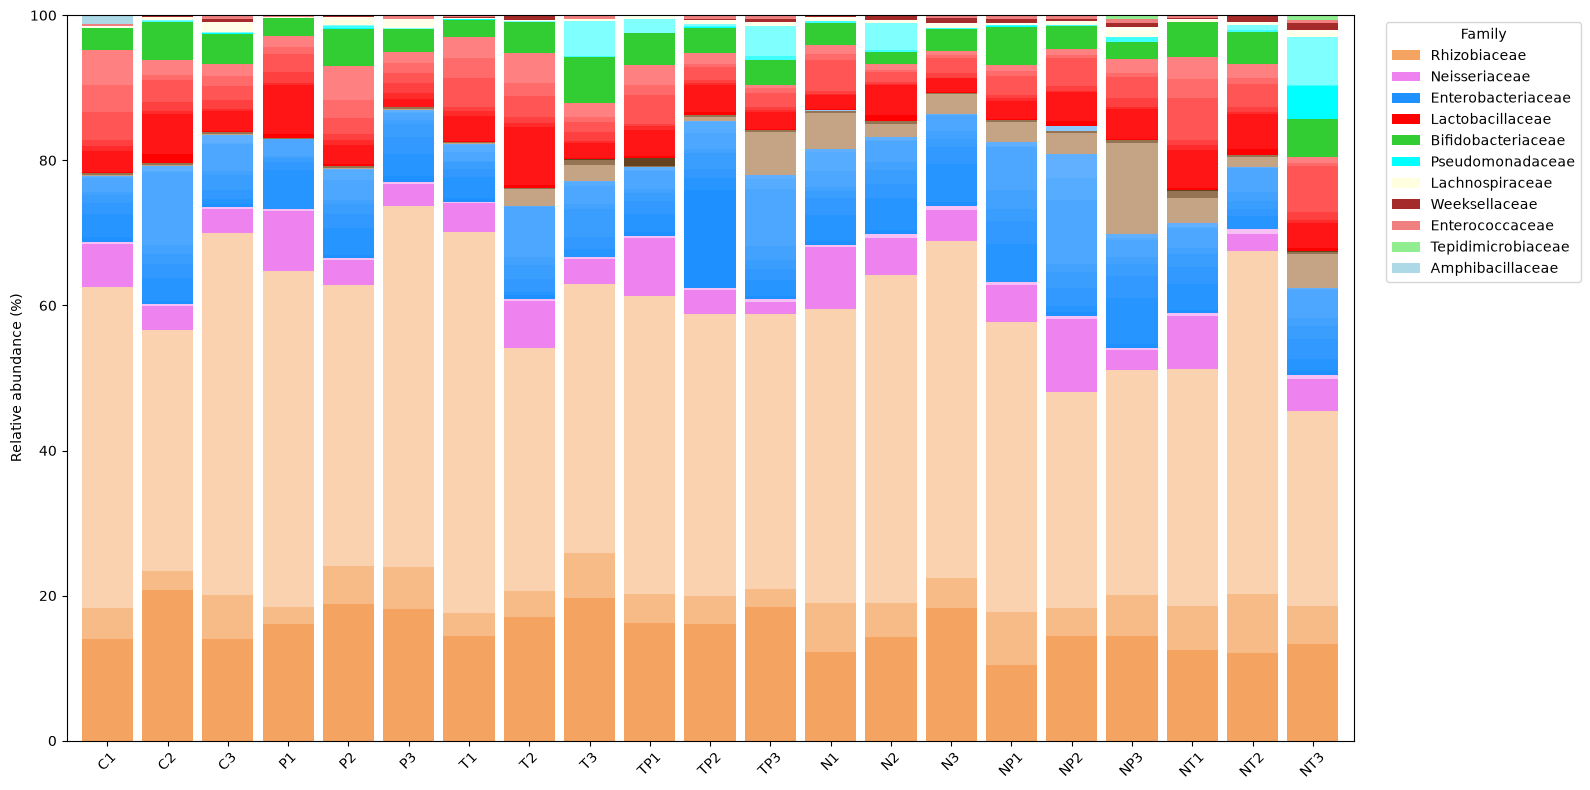

In [201]:
family_colors = {
    "Rhizobiaceae": "sandybrown",  # Bartonellaceae
    "Neisseriaceae": "violet",
    "Enterobacteriaceae": "dodgerblue",  # Orbaceae
    "Lactobacillaceae": "red",
    "Leuconostocaceae": "orange",
    "Bifidobacteriaceae": "limegreen",
    # not in the original paper
    "Pseudomonadaceae": "cyan",
    "Lachnospiraceae": "lightyellow",
    "Weeksellaceae": "brown",
    "Enterococcaceae": "lightcoral",
    "Tepidimicrobiaceae": "lightgreen",
    "Amphibacillaceae": "lightblue",
}

def make_family_shades(base_color, n):
    if n <= 1:
        return [mcolors.to_hex(base_color)]
    base_rgb = np.array(mcolors.to_rgb(base_color))
    white = np.array([1.0, 1.0, 1.0])
    factors = np.linspace(0.0, 0.5, n)
    return [mcolors.to_hex(base_rgb * (1 - f) + white * f) for f in factors]

def make_color_gradient(start_color, end_color, n):
    if n <= 1:
        return [mcolors.to_hex(start_color)]
    start_rgb = np.array(mcolors.to_rgb(start_color))
    end_rgb = np.array(mcolors.to_rgb(end_color))
    factors = np.linspace(0.0, 1.0, n)
    return [mcolors.to_hex(start_rgb * (1 - f) + end_rgb * f) for f in factors]

family_order = list(family_colors.keys())
family_rank = {family: rank for rank, family in enumerate(family_order)}

# Reorder species rows so stacked bars follow the requested family order
index_df = species_abund_df.index.to_frame(index=False)
index_df["sort_rank"] = index_df["Family"].map(family_rank).fillna(len(family_order)).astype(int)
index_df = index_df.sort_values(["sort_rank", "Family", "Genus", "Species"], kind="stable")
ordered_index = pd.MultiIndex.from_frame(index_df[["Family", "Genus", "Species"]])
species_abund_df_ordered = species_abund_df.loc[ordered_index]

# Default colors: same family hue, different shade within family
default_color_map = {}
for family_name, group in index_df.groupby("Family", sort=False):
    base_color = family_colors.get(family_name, "gray")
    shades = make_family_shades(base_color, len(group))
    for (_, row), shade in zip(group.iterrows(), shades):
        default_color_map[(row["Family"], row["Genus"], row["Species"])] = shade

# Special overrides requested by user
providencia_count = index_df["Genus"].astype(str).str.lower().str.startswith("providencia").sum()
providencia_shades = iter(make_color_gradient("#c4a484", "#654321", providencia_count))

species_colors = []
for _, row in index_df.iterrows():
    family_name = row["Family"]
    genus_name = str(row["Genus"]).strip().lower()
    species_name = str(row["Species"]).strip().lower()
    key = (row["Family"], row["Genus"], row["Species"])
    if genus_name.startswith("arsenophonus") and species_name == "apicola":
        color = "black"
    elif genus_name.startswith("proteus"):
        color = "#c4a484"  # light brown
    elif genus_name.startswith("providencia"):
        color = next(providencia_shades)
    else:
        color = default_color_map.get(key, family_colors.get(family_name, "gray"))
    species_colors.append(color)

fig, ax = plt.subplots(figsize=(16, 8))
species_abund_df_ordered.T.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=species_colors,
    width=0.85,
    legend=False,
 )

ax.set_ylabel("Relative abundance (%)")
ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=45)

present_families = [family for family in family_order if family in set(index_df["Family"])]
legend_handles = [
    Patch(facecolor=family_colors.get(family, "gray"), label=family)
    for family in present_families
]
ax.legend(handles=legend_handles, title="Family", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
png_fp = result_dp / "taxonomy_relative_abundance_biplot.png"
fig.savefig(png_fp, dpi=300, bbox_inches="tight")
plt.show()

### PCA

Saved PCA biplot to: ../results/bee-use-case/taxonomy_pca_biplot.png


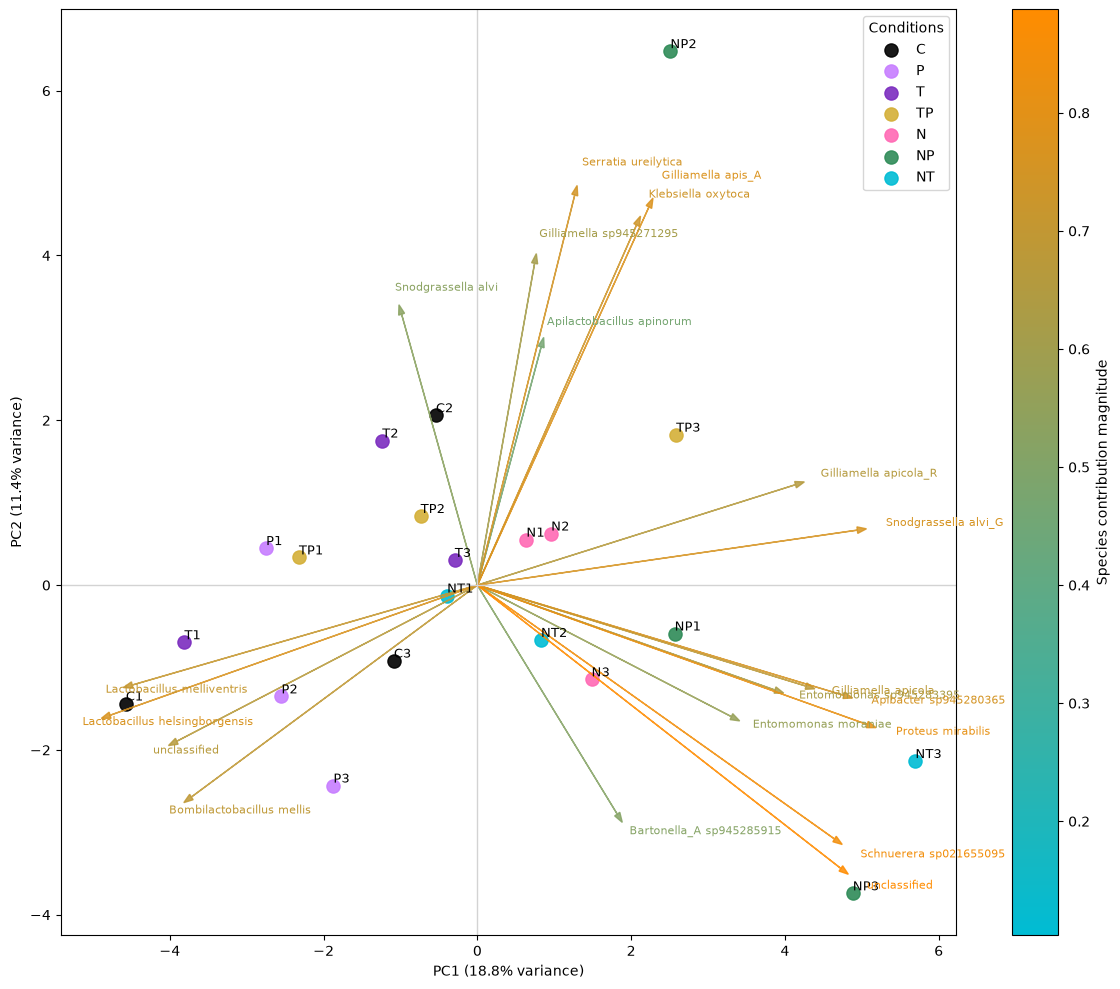

,PC1,PC2,Category
C1,-4.570935,-1.436631,C
C2,-0.538517,2.061712,C
C3,-1.085125,-0.917092,C
P1,-2.747159,0.449632,P
P2,-2.547741,-1.350481,P
P3,-1.872148,-2.433057,P
T1,-3.809287,-0.693279,T
T2,-1.236752,1.754782,T
T3,-0.292957,0.305178,T
TP1,-2.320190,0.335765,TP


In [188]:
sample_matrix = species_abund_df.select_dtypes(include=[np.number]).T

scaled_sample_matrix = StandardScaler().fit_transform(sample_matrix)
pca = PCA(n_components=2)
sample_scores = pca.fit_transform(scaled_sample_matrix)
species_loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

sample_scores_df = pd.DataFrame(sample_scores, index=sample_matrix.index, columns=["PC1", "PC2"])
sample_scores_df["Category"] = (
    sample_scores_df.index.to_series()
    .str.extract(r"^(NT|NP|TP|C|T|P|N)", expand=False)
    .fillna("Other")
)

category_palette = {
    "C": "#000000",
    "T": "#7b2cbf",
    "P": "#c77dff",
    "N": "#ff69b4",
    "NT": "#00bcd4",
    "NP": "#2e8b57",
    "TP": "#d4af37",
    "Other": "#6c757d",
}

species_contribution = np.linalg.norm(species_loadings, axis=1)
contribution_norm = plt.Normalize(species_contribution.min(), species_contribution.max())
arrow_cmap = LinearSegmentedColormap.from_list("cyan_orange", ["#00bcd4", "#ff8c00"])
arrow_colors = arrow_cmap(contribution_norm(species_contribution))

top_species_idx = np.argsort(species_contribution)[-20:]
score_limit = np.abs(sample_scores_df[["PC1", "PC2"]].to_numpy()).max()
loading_limit = np.abs(species_loadings[top_species_idx]).max()
arrow_scale = 1.0 if loading_limit == 0 else (score_limit / loading_limit) * 0.8

fig, ax = plt.subplots(figsize=(12, 10))

for category, frame in sample_scores_df.groupby("Category", sort=False):
    ax.scatter(
        frame["PC1"],
        frame["PC2"],
        s=90,
        color=category_palette.get(category, category_palette["Other"]),
        label=category,
        alpha=0.9,
    )
    for sample_name, row in frame.iterrows():
        ax.text(row["PC1"], row["PC2"], sample_name, fontsize=9, ha="left", va="bottom")

for idx in top_species_idx:
    species_name = species_abund_df.index[idx][2]
    x_loading = species_loadings[idx, 0] * arrow_scale
    y_loading = species_loadings[idx, 1] * arrow_scale
    ax.arrow(
        0,
        0,
        x_loading,
        y_loading,
        color=arrow_colors[idx],
        alpha=0.85,
        width=0.002,
        head_width=0.08,
        length_includes_head=True,
    )
    ax.text(x_loading * 1.05, y_loading * 1.05, species_name, color=arrow_colors[idx], fontsize=8)

explained_variance = pca.explained_variance_ratio_ * 100
ax.axhline(0, color="lightgray", linewidth=1)
ax.axvline(0, color="lightgray", linewidth=1)
ax.set_xlabel(f"PC1 ({explained_variance[0]:.1f}% variance)")
ax.set_ylabel(f"PC2 ({explained_variance[1]:.1f}% variance)")
ax.legend(title="Conditions")

sm = plt.cm.ScalarMappable(cmap=arrow_cmap, norm=contribution_norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Species contribution magnitude")

plt.tight_layout()
png_fp = result_dp / "taxonomy_pca_biplot.png"
fig.savefig(png_fp, dpi=300, bbox_inches="tight")
print(f"Saved PCA biplot to: {png_fp}")
plt.show()

sample_scores_df

In [106]:
species_loadings

array([[ 0.66804367, -0.30648467],
       [ 0.22468819,  0.41941892],
       [ 0.05378232,  0.42234662],
       [-0.06695601,  0.00461451],
       [ 0.02249602,  0.11251996],
       [ 0.35098031, -0.32360899],
       [ 0.27148992,  0.09753058],
       [-0.50650791, -0.04838075],
       [ 0.47906516, -0.1063037 ],
       [ 0.45112008, -0.19480852],
       [ 0.55038577, -0.38157759],
       [ 0.12799848, -0.43584903],
       [ 0.08467503, -0.20524486],
       [ 0.73235725, -0.06468219],
       [ 0.35000516,  0.11095733],
       [ 0.68193382, -0.01340307],
       [ 0.51531686,  0.57574856],
       [ 0.25174849,  0.57119297],
       [ 0.47213453,  0.65402955],
       [ 0.29066546,  0.28962461],
       [-0.6983872 ,  0.10776568],
       [-0.61070729,  0.17303628],
       [ 0.23820397, -0.46830729],
       [ 0.72522923, -0.29193618],
       [ 0.3280239 ,  0.0878088 ],
       [ 0.24676874,  0.05637286],
       [-0.20938607,  0.113416  ],
       [ 0.62434654, -0.43222998],
       [ 0.35156054,

## Comparison of MAGs taxonomy with original study

In [82]:
count = df_expert[
    df_expert["Origin"].astype(str).str.contains("Built MAG", na=False)
    & (df_expert["Differences between NCBI and GTDB taxonomies"] == "Yes")].shape[0]
print(f"Number of MAGs with differences between NCBI and GTDB taxonomies: {count}")

Number of MAGs with differences between NCBI and GTDB taxonomies: 20


In [ ]:
# Count in how many MAGs a KEGG pathway reaches a given completeness threshold
kegg_pathway_mag_counts_df = pd.DataFrame(index=kegg_path_df.columns)

for threshold in thresholds:
    kegg_pathway_mag_counts_df[f"MAGs with completness >= {threshold}%"] = (kegg_path_df >= threshold).sum(axis=0)

kegg_pathway_mag_counts_df = kegg_pathway_mag_counts_df.sort_values(by="MAGs with completness >= 50%", ascending=False)
kegg_pathway_mag_counts_df

,MAGs with completness >= 50%,MAGs with completness >= 75%,MAGs with completness >= 100%
"Guanine ribonucleotide biosynthesis, IMP => GDP,GTP",32,29,17
"Nucleotide sugar biosynthesis, glucose => UDP-glucose",32,18,18
"Glycolysis (Embden-Meyerhof pathway), glucose => pyruvate",32,27,13
"C1-unit interconversion, prokaryotes",32,14,14
Pentose phosphate pathway (Pentose phosphate cycle),32,23,12
...,...,...,...
"Pyocyanine biosynthesis, chorismate => pyocyanine",0,0,0
Hydroxypropionate-hydroxybutylate cycle,0,0,0
"Incomplete reductive citrate cycle, acetyl-CoA => oxoglutarate",0,0,0
"Inositol phosphate metabolism, Ins(1,3,4,5)P4 => Ins(1,3,4)P3 => myo-inositol",0,0,0


### Statistics for MAGs origin

In [8]:
origin_df = df_expert["Origin"].value_counts(dropna=False).to_frame("count")
origin_df

,count
Origin,
"Built MAG, Species listed in the paper",19
Built MAG,19
Species listed in the paper,10


In [9]:
print(f"Percentage of species identified by MAGs listed in the paper: {100*origin_df.loc['Built MAG, Species listed in the paper', 'count']/levels.loc['Species', 'count'] if levels.loc['Species', 'count'] > 0 else None}")

Percentage of species identified by MAGs listed in the paper: 59.375


### Species identified by MAGs

#### Concordant = corresponding to species listed in the paper 

In [10]:
concordant_mags = df_expert.query("Origin == 'Built MAG, Species listed in the paper' and Species.notna()")
concordant_mags

,Name,Domain,Phylum,Class,Order,Family,Genus,Species,Species found in the paper,Differences between NCBI and GTDB taxonomies,...,Origin,Expected in such environment?,Microbiota type,Comment,Expert name,Species-level MAG count,Completeness,Contamination,Genome Size,GC Content
0,SRR24759604_bin_107333,Bacteria,Actinomycetota,Actinomycetes,Actinomycetales,Bifidobacteriaceae,Bifidobacterium,Bifidobacterium indicum,Bifidobacterium coryneforme,Yes,...,"Built MAG, Species listed in the paper",Yes,Core,Listed in the paper (Figure ?),NaN,8.0,96.81,2.42,1882718.0,0.61
2,SRR24759612_bin_52183,Bacteria,Bacillota,Bacilli,Bacillales_D,Amphibacillaceae,Virgibacillus,Virgibacillus proomii_B,Virgibacillus proomii,Yes,...,"Built MAG, Species listed in the paper",Yes,Non-core,listed in the paper as Virgibacillus proomis (...,NaN,1.0,99.85,0.99,4560752.0,0.36
4,SRR24759605_bin_65734,Bacteria,Bacillota,Bacilli,Lactobacillales,Lactobacillaceae,Apilactobacillus,Apilactobacillus apinorum,Apilactobacillus apinorum,No,...,"Built MAG, Species listed in the paper",Yes,NaN,listed in the paper (Figure 2),NaN,4.0,75.77,1.20,1054200.0,0.34
5,SRR24759606_bin_54634,Bacteria,Bacillota,Bacilli,Lactobacillales,Lactobacillaceae,Apilactobacillus,Apilactobacillus kunkeei_C,Apilactobacillus kunkeei,Yes,...,"Built MAG, Species listed in the paper",Yes,Non-core,NaN,NaN,15.0,98.66,1.47,1404564.0,0.37
6,SRR24759613_bin_56459,Bacteria,Bacillota,Bacilli,Lactobacillales,Lactobacillaceae,Bombilactobacillus,Bombilactobacillus mellis,Bombilactobacillus mellis,No,...,"Built MAG, Species listed in the paper",Yes,Core,Listed in the paper,NaN,4.0,85.51,0.83,1473654.0,0.37
8,SRR24759613_bin_39911,Bacteria,Bacillota,Bacilli,Lactobacillales,Lactobacillaceae,Fructobacillus,Fructobacillus fructosus,Fructobacillus fructosus,No,...,"Built MAG, Species listed in the paper",Yes,NaN,listed in the paper (Figure 2),NaN,17.0,97.52,0.23,1276613.0,0.45
9,SRR24759604_bin_148146,Bacteria,Bacillota,Bacilli,Lactobacillales,Lactobacillaceae,Lactobacillus,Lactobacillus apis,Lactobacillus apis,No,...,"Built MAG, Species listed in the paper",Yes,Core,Listed in the paper,NaN,1.0,75.44,2.08,1396370.0,0.37
10,SRR24759603_bin_355,Bacteria,Bacillota,Bacilli,Lactobacillales,Lactobacillaceae,Lactobacillus,Lactobacillus helsingborgensis,Lactobacillus helsingborgensis,No,...,"Built MAG, Species listed in the paper",Yes,Core,Listed in the paper,NaN,6.0,83.57,2.45,1543830.0,0.37
11,SRR24759616_bin_28305,Bacteria,Bacillota,Bacilli,Lactobacillales,Lactobacillaceae,Lactobacillus,Lactobacillus melliventris,Lactobacillus melliventris,No,...,"Built MAG, Species listed in the paper",Yes,Core,Listed in the paper,NaN,3.0,77.35,3.09,1403520.0,0.36
16,SRR24759613_bin_105744,Bacteria,Bacillota_A,Clostridia,Lachnospirales,Lachnospiraceae,Novisyntrophococcus,Novisyntrophococcus liquoris,Blautia liquoris,Yes,...,"Built MAG, Species listed in the paper",Yes,NaN,listed in the paper (Figure 4),NaN,9.0,98.77,0.13,3595826.0,0.42


In [11]:
concordant_mags[["Completeness", "Contamination", "Genome Size"]].describe()

,Completeness,Contamination,Genome Size
count,19.000000,19.000000,1.900000e+01
mean,89.672632,1.898421,2.436661e+06
std,10.374308,2.317871,1.258594e+06
min,75.030000,0.050000,1.054200e+06
25%,78.005000,0.220000,1.439109e+06
50%,95.790000,1.200000,2.035396e+06
75%,99.170000,2.435000,3.357385e+06
max,100.000000,9.790000,5.438933e+06


#### Non concordant = NOT corresponding to species listed in the paper

In [12]:
non_concordant_mags = df_expert.query("Origin == 'Built MAG' and Species.notna()")
non_concordant_mags

,Name,Domain,Phylum,Class,Order,Family,Genus,Species,Species found in the paper,Differences between NCBI and GTDB taxonomies,...,Origin,Expected in such environment?,Microbiota type,Comment,Expert name,Species-level MAG count,Completeness,Contamination,Genome Size,GC Content
3,SRR24759610_bin_19,Bacteria,Bacillota,Bacilli,Lactobacillales,Enterococcaceae,Enterococcus,Enterococcus faecalis,NaN,No,...,Built MAG,NaN,NaN,No mention in the paper,NaN,7.0,99.53,0.39,2744679.0,0.38
17,SRR24759600_bin_132439,Bacteria,Bacillota_A,Clostridia,Tissierellales,Tepidimicrobiaceae,Schnuerera,Schnuerera sp021655095,NaN,Yes,...,Built MAG,NaN,NaN,No mention in the paper.,NaN,1.0,99.64,0.55,2747383.0,0.31
18,SRR24759600_bin_66323,Bacteria,Bacteroidota,Bacteroidia,Flavobacteriales,Weeksellaceae,Apibacter,Apibacter sp945280365,NaN,Yes,...,Built MAG,NaN,NaN,Taxonomy issue?,NaN,6.0,99.89,0.05,2514634.0,0.30
22,SRR24759600_bin_138516,Bacteria,Pseudomonadota,Alphaproteobacteria,Rhizobiales,Rhizobiaceae,Bartonella_A,Bartonella_A choladocola,NaN,Yes,...,Built MAG,NaN,Non-core,NaN,NaN,2.0,87.71,1.61,1731863.0,0.46
23,SRR24759613_bin_38453,Bacteria,Pseudomonadota,Alphaproteobacteria,Rhizobiales,Rhizobiaceae,Bartonella_A,Bartonella_A sp945285915,NaN,Yes,...,Built MAG,NaN,NaN,Correspond to Bartonella api?,NaN,1.0,88.24,1.45,2140910.0,0.42
26,SRR24759605_bin_35353,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Arsenophonus,Arsenophonus apicola,NaN,No,...,Built MAG,NaN,NaN,But Arsenophonus spp listed in the paper,NaN,1.0,99.99,0.70,3251563.0,0.37
30,SRR24759607_bin_27236,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Gilliamella,Gilliamella apicola_N,NaN,Yes,...,Built MAG,NaN,NaN,same as above?,NaN,1.0,78.78,7.15,2195362.0,0.34
31,SRR24759615_bin_55433,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Gilliamella,Gilliamella apicola_R,NaN,Yes,...,Built MAG,NaN,NaN,same as above?,NaN,1.0,75.72,6.96,2390088.0,0.35
33,SRR24759598_bin_119213,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Gilliamella,Gilliamella sp945271295,NaN,Yes,...,Built MAG,NaN,NaN,Taxonomy issue?,NaN,3.0,85.98,0.91,2504613.0,0.34
38,SRR24759602_bin_50685,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Providencia,Providencia rettgeri,NaN,Yes,...,Built MAG,NaN,NaN,But Providencia spp. listed in the paper,NaN,1.0,87.11,7.31,4418213.0,0.40


In [13]:
non_concordant_mags[["Completeness", "Contamination", "Genome Size"]].describe()

,Completeness,Contamination,Genome Size
count,13.000000,13.000000,1.300000e+01
mean,91.373077,2.381538,2.969065e+06
std,8.858552,2.769485,1.066318e+06
min,75.720000,0.050000,1.731863e+06
25%,85.980000,0.550000,2.246952e+06
50%,88.240000,1.450000,2.514634e+06
75%,99.890000,1.810000,3.251563e+06
max,100.000000,7.310000,5.131086e+06


#### Comparison of completess and contamination between concordant and non-concordant species

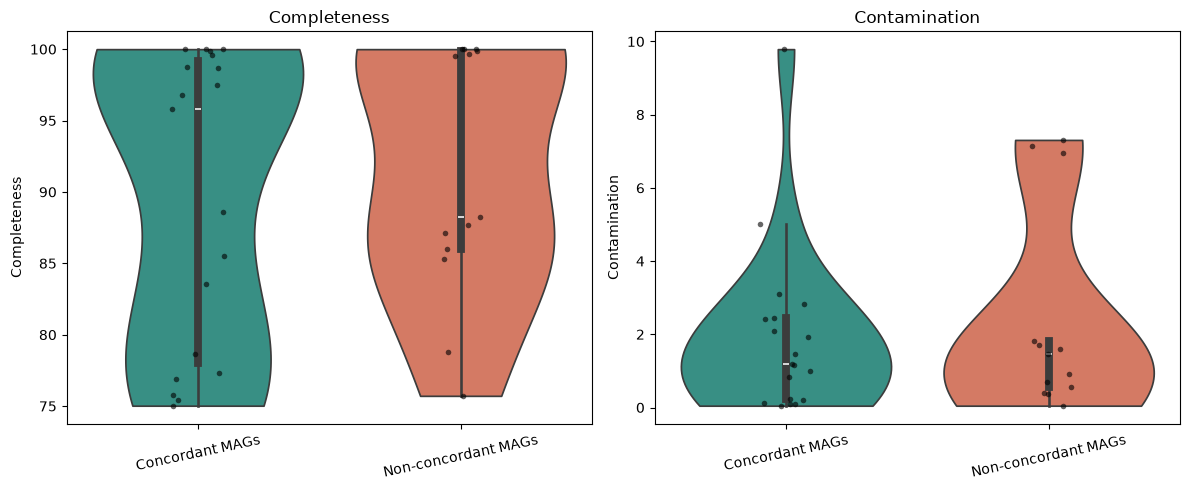

In [14]:
metrics = ["Completeness", "Contamination"]
group_order = ["Concordant MAGs", "Non-concordant MAGs"]

plot_frames = []
for group_name, frame in [
    ("Concordant MAGs", concordant_mags),
    ("Non-concordant MAGs", non_concordant_mags),
]:
    subset = frame[metrics].copy()
    for metric in metrics:
        subset[metric] = pd.to_numeric(subset[metric], errors="coerce")
    subset["Group"] = group_name
    plot_frames.append(subset)

plot_df = pd.concat(plot_frames, ignore_index=True)

palette = {
    "Concordant MAGs": "#2a9d8f",
    "Non-concordant MAGs": "#e76f51",
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, metric in zip(axes, metrics):
    sns.violinplot(
        data=plot_df,
        x="Group",
        y=metric,
        hue="Group",
        order=group_order,
        hue_order=group_order,
        palette=palette,
        cut=0,
        inner="box",
        legend=False,
        ax=ax,
    )
    sns.stripplot(
        data=plot_df,
        x="Group",
        y=metric,
        order=group_order,
        color="black",
        alpha=0.6,
        size=4,
        ax=ax,
    )
    ax.set_xlabel("")
    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=12)

plt.tight_layout()
plt.show()

# Functional annotations

## Bakta annotations

In [ ]:
bakta_annot_df = reps_df.filter(regex="^bakta_").copy()
bakta_annot_df.columns = bakta_annot_df.columns.str.replace("^bakta_", "", regex=True)
bakta_annot_df.describe()

,CDSs,CRISPR arrays,gaps,hypotheticals,ncRNA regions,ncRNAs,oriCs,oriTs,oriVs,pseudogenes,rRNAs,sORFs,signal peptides,tRNAs,tmRNAs
count,38.000000,38.000000,38.0,38.000000,38.000000,38.000000,38.000000,38.000000,38.0,38.000000,38.000000,38.000000,38.0,38.000000,38.000000
mean,2439.526316,1.263158,0.0,245.131579,19.157895,15.342105,0.552632,0.052632,0.0,13.421053,2.000000,1.210526,0.0,40.000000,0.684211
std,1036.460681,2.101276,0.0,212.441810,13.909993,17.134249,0.645038,0.226294,0.0,13.769594,2.493234,2.672764,0.0,15.502397,0.471069
min,977.000000,0.000000,0.0,42.000000,2.000000,2.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,13.000000,0.000000
25%,1610.750000,0.000000,0.0,81.750000,9.000000,5.000000,0.000000,0.000000,0.0,4.250000,0.000000,0.000000,0.0,30.250000,0.000000
50%,2144.500000,0.000000,0.0,186.000000,14.500000,6.500000,0.000000,0.000000,0.0,8.000000,1.500000,0.000000,0.0,38.500000,1.000000
75%,3090.250000,1.750000,0.0,304.500000,26.750000,21.500000,1.000000,0.000000,0.0,16.000000,3.000000,1.000000,0.0,50.000000,1.000000
max,4991.000000,9.000000,0.0,874.000000,57.000000,73.000000,2.000000,1.000000,0.0,57.000000,13.000000,12.000000,0.0,71.000000,1.000000


## KEGG pathways

In [63]:
kegg_path_df = reps_df.filter(regex="^kegg_").copy()
kegg_path_df.columns = kegg_path_df.columns.str.replace("^kegg_", "", regex=True)
kegg_path_df = kegg_path_df.fillna(0)
print(f"Rows: {kegg_path_df.shape[0]}")
print(f"Columns: {kegg_path_df.shape[1]}")
kegg_path_df = kegg_path_df.loc[:, (kegg_path_df != 0).any(axis=0)]
kegg_path_df = kegg_path_df.loc[(kegg_path_df != 0).any(axis=1), :]
print("After removing rows and columns with all zeros:")
print(f"Rows: {kegg_path_df.shape[0]}")
print(f"Columns: {kegg_path_df.shape[1]}")
kegg_path_df.head(10)

Rows: 38
Columns: 306
After removing rows and columns with all zeros:
Rows: 32
Columns: 301


,3-Hydroxypropionate bi-cycle,"9-membered enediyne core biosynthesis, malonyl-CoA => 3-hydroxyhexadeca-4,6,8,10,12,14-hexaenoyl-ACP => 9-membered enediyne core",ADP-L-glycero-D-manno-heptose biosynthesis,"Acetyl-CoA pathway, CO2 => acetyl-CoA",Acylglycerol degradation,"Adenine ribonucleotide biosynthesis, IMP => ADP,ATP","Adenine ribonucleotide degradation, AMP => Urate","Aerobactin biosynthesis, lysine => aerobactin","Anammox, nitrite + ammonia => nitrogen","Anthranilate degradation, anthranilate => catechol",...,"Vancomycin resistance, D-Ala-D-Ser type","Vibrio cholerae pathogenicity signature, cholera toxins","Vibrio cholerae pathogenicity signature, toxin coregulated pilus","Xanthomonas spp. pathogenicity signature, T3SS and effectors","Xylene degradation, xylene => methylbenzoate","beta-Carotene biosynthesis, GGAP => beta-carotene","beta-Lactam resistance, Bla system",beta-Oxidation,"beta-Oxidation, acyl-CoA synthesis",dTDP-L-rhamnose biosynthesis
1,16.67,0.00,100.0,0.0,0.0,100.0,66.67,0.0,0.0,25.00,...,0.0,0.00,0.00,6.82,0.00,0.0,0.00,100.00,100.0,83.33
2,16.67,0.00,100.0,0.0,50.0,100.0,66.67,25.0,0.0,0.00,...,0.0,0.00,0.00,5.68,0.00,0.0,0.00,100.00,100.0,100.00
3,16.67,0.00,100.0,0.0,50.0,100.0,100.00,25.0,0.0,0.00,...,0.0,0.00,7.14,10.23,0.00,0.0,33.33,100.00,100.0,83.33
4,22.22,0.00,100.0,0.0,0.0,100.0,66.67,0.0,0.0,25.00,...,0.0,0.00,0.00,0.00,33.33,0.0,33.33,100.00,100.0,83.33
5,16.67,0.00,100.0,0.0,0.0,100.0,66.67,25.0,0.0,33.33,...,0.0,0.00,0.00,0.00,0.00,0.0,0.00,100.00,100.0,83.33
6,16.67,0.00,80.0,0.0,50.0,100.0,66.67,0.0,0.0,0.00,...,0.0,0.00,0.00,0.00,0.00,0.0,0.00,100.00,100.0,100.00
7,16.67,0.00,80.0,0.0,50.0,100.0,66.67,0.0,0.0,0.00,...,0.0,16.67,0.00,0.00,0.00,0.0,0.00,66.67,100.0,100.00
8,16.67,0.00,0.0,0.0,0.0,100.0,66.67,0.0,0.0,0.00,...,0.0,0.00,0.00,0.00,0.00,0.0,33.33,0.00,100.0,100.00
9,22.22,6.25,60.0,0.0,50.0,100.0,66.67,0.0,0.0,0.00,...,0.0,0.00,0.00,0.00,0.00,0.0,100.00,100.00,100.0,0.00
10,11.11,0.00,0.0,0.0,0.0,50.0,77.78,0.0,0.0,0.00,...,0.0,0.00,0.00,1.14,0.00,0.0,33.33,0.00,0.0,33.33


In [49]:
# Count how many KEGG pathways reach a given completeness threshold for each MAG
thresholds = [50, 75, 100]
kegg_path_counts_df = pd.DataFrame(index=kegg_path_df.index)

for threshold in thresholds:
    kegg_path_counts_df[f"pathways with completeness >= {threshold}%"] = (kegg_path_df >= threshold).sum(axis=1)

kegg_path_counts_df = kegg_path_counts_df.sort_values(by="pathways with completeness >= 50%", ascending=False)
kegg_path_counts_df.describe()

,pathways with completeness >= 50%,pathways with completeness >= 75%,pathways with completeness >= 100%
count,32.000000,32.00000,32.000000
mean,96.593750,58.78125,40.312500
std,37.268736,27.51508,23.647188
min,31.000000,10.00000,5.000000
25%,73.500000,41.50000,24.500000
50%,94.500000,56.50000,37.000000
75%,122.500000,79.25000,52.000000
max,171.000000,116.00000,98.000000


In [ ]:
# Count in how many MAGs a KEGG pathway reaches a given completeness threshold
kegg_pathway_mag_counts_df = pd.DataFrame(index=kegg_path_df.columns)

for threshold in thresholds:
    kegg_pathway_mag_counts_df[f"MAGs with completness >= {threshold}%"] = (kegg_path_df >= threshold).sum(axis=0)

kegg_pathway_mag_counts_df = kegg_pathway_mag_counts_df.sort_values(by="MAGs with completness >= 50%", ascending=False)
kegg_pathway_mag_counts_df

,MAGs with completness >= 50%,MAGs with completness >= 75%,MAGs with completness >= 100%
"Guanine ribonucleotide biosynthesis, IMP => GDP,GTP",32,29,17
"Nucleotide sugar biosynthesis, glucose => UDP-glucose",32,18,18
"Glycolysis (Embden-Meyerhof pathway), glucose => pyruvate",32,27,13
"C1-unit interconversion, prokaryotes",32,14,14
Pentose phosphate pathway (Pentose phosphate cycle),32,23,12
...,...,...,...
"Pyocyanine biosynthesis, chorismate => pyocyanine",0,0,0
Hydroxypropionate-hydroxybutylate cycle,0,0,0
"Incomplete reductive citrate cycle, acetyl-CoA => oxoglutarate",0,0,0
"Inositol phosphate metabolism, Ins(1,3,4,5)P4 => Ins(1,3,4)P3 => myo-inositol",0,0,0


In [66]:
print(f"Number of pathways with completeness < 50% in all MAG: {((kegg_path_df < 50).all(axis=0)).sum()}")
print(f"Number of pathways with completeness < 75% in all MAG: {((kegg_path_df < 75).all(axis=0)).sum()}")
print(f"Number of pathways with completeness >= 50 % in all MAG: {((kegg_path_df >= 50).all(axis=0)).sum()}")
print(f"Number of pathways with completeness >= 75 % in all MAG: {((kegg_path_df >= 75).all(axis=0)).sum()}")


Number of pathways with completeness < 50% in all MAG: 90
Number of pathways with completeness < 75% in all MAG: 144
Number of pathways with completeness >= 50 % in all MAG: 6
Number of pathways with completeness >= 75 % in all MAG: 0


In [68]:
kegg_pathway_mag_counts_df.index[kegg_pathway_mag_counts_df.iloc[:, 0].eq(32)].tolist()

['Guanine ribonucleotide biosynthesis, IMP => GDP,GTP',
 'Nucleotide sugar biosynthesis, glucose => UDP-glucose',
 'Glycolysis (Embden-Meyerhof pathway), glucose => pyruvate',
 'C1-unit interconversion, prokaryotes',
 'Pentose phosphate pathway (Pentose phosphate cycle)',
 'F-type ATPase, prokaryotes and chloroplasts']